In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [2]:
# Path of Iris CSV file
file_path = "C:/Users/Kandarp Malkan/OneDrive/Desktop/DL_Material/iris.csv"
# file_path = "Z:/iris.csv" FOR THE LAB/ EXAM ENVIRONMENT

# Load dataset
df = pd.read_csv(file_path)

# Display first 5 rows
df.head()

,Id,sepal_length,sepal_width,petal_length,petal_width,species
0,1,5.1,3.5,1.4,0.2,setosa
1,2,4.9,3.0,1.4,0.2,setosa
2,3,4.7,3.2,1.3,0.2,setosa
3,4,4.6,3.1,1.5,0.2,setosa
4,5,5.0,3.6,1.4,0.2,setosa


In [3]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
print(df.head())

Dataset Shape: (150, 6)

Column Names:
Index(['Id', 'sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

First 5 Rows:
   Id  sepal_length  sepal_width  petal_length  petal_width species
0   1           5.1          3.5           1.4          0.2  setosa
1   2           4.9          3.0           1.4          0.2  setosa
2   3           4.7          3.2           1.3          0.2  setosa
3   4           4.6          3.1           1.5          0.2  setosa
4   5           5.0          3.6           1.4          0.2  setosa


In [4]:
# Input features
X = df[
    [
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
]

# Target
y = df["species"]

print("Input Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Input Features:
   sepal_length  sepal_width  petal_length  petal_width
0           5.1          3.5           1.4          0.2
1           4.9          3.0           1.4          0.2
2           4.7          3.2           1.3          0.2
3           4.6          3.1           1.5          0.2
4           5.0          3.6           1.4          0.2

Target:
0    setosa
1    setosa
2    setosa
3    setosa
4    setosa
Name: species, dtype: object


In [5]:
label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Encoded Labels:")
print(y_encoded[:10])

print("\nClass Names:")
print(label_encoder.classes_)

Encoded Labels:
[0 0 0 0 0 0 0 0 0 0]

Class Names:
['setosa' 'versicolor' 'virginica']


In [ ]:
# As we have multiclass classification problem we need to convert (setosa, virginica) -> label -> one hot encoding (as using categorical cross entropy)

y_onehot = tf.keras.utils.to_categorical(
    y_encoded,
    num_classes=3
)

print("One-Hot Encoded Target:")
print(y_onehot[:5])

One-Hot Encoded Target:
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_onehot,
    test_size=0.20,
    random_state=42,
    stratify=y_encoded
)

print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

Training data: (120, 4)
Testing data : (30, 4)


In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

print("Feature normalization completed.")

Feature normalization completed.


In [10]:
dropout_model = tf.keras.Sequential([

    tf.keras.layers.Input(shape=(4,)),

    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(16,activation="relu"),
    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(3, activation="softmax")
])

dropout_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 32)                160       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 16)                528       
                                                                 
 dropout_1 (Dropout)         (None, 16)                0         
                                                                 
 dense_2 (Dense)             (None, 3)                 51        
                                                                 
Total params: 739
Trainable params: 739
Non-trainable params: 0
_________________________________________________________________


In [11]:
dropout_model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Dropout model compiled successfully.")

Dropout model compiled successfully.


In [12]:
dropout_history = dropout_model.fit(
    X_train,
    y_train,
    validation_split=0.20,
    epochs=20,
    batch_size=16,
    verbose=1
)

Epoch 1/20
6/6 [==============================] - 2s 55ms/step - loss: 1.2063 - accuracy: 0.2708 - val_loss: 1.0893 - val_accuracy: 0.4583
Epoch 2/20
6/6 [==============================] - 0s 7ms/step - loss: 1.1047 - accuracy: 0.4167 - val_loss: 1.0323 - val_accuracy: 0.5000
Epoch 3/20
6/6 [==============================] - 0s 7ms/step - loss: 1.0294 - accuracy: 0.5312 - val_loss: 0.9837 - val_accuracy: 0.5417
Epoch 4/20
6/6 [==============================] - 0s 8ms/step - loss: 1.0005 - accuracy: 0.4792 - val_loss: 0.9397 - val_accuracy: 0.5417
Epoch 5/20
6/6 [==============================] - 0s 8ms/step - loss: 0.9848 - accuracy: 0.5208 - val_loss: 0.9006 - val_accuracy: 0.6250
Epoch 6/20
6/6 [==============================] - 0s 8ms/step - loss: 0.9357 - accuracy: 0.5521 - val_loss: 0.8652 - val_accuracy: 0.6250
Epoch 7/20
6/6 [==============================] - 0s 9ms/step - loss: 0.9000 - accuracy: 0.5625 - val_loss: 0.8354 - val_accuracy: 0.7083
Epoch 8/20
6/6 [=================

In [13]:
test_loss, test_accuracy = dropout_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", test_loss)

print(
    "Test Accuracy: {:.2f}%".format(
        test_accuracy * 100
    )
)

Test Loss: 0.5157167315483093
Test Accuracy: 73.33%


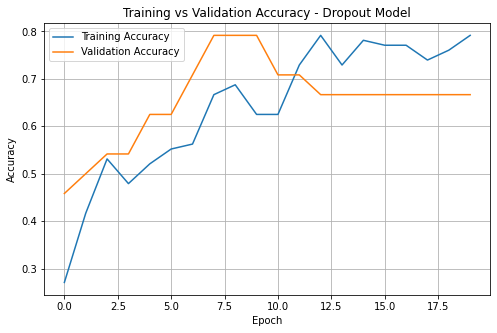

In [14]:
plt.figure(figsize=(8, 5))

plt.plot(
    dropout_history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    dropout_history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy - Dropout Model")

plt.legend()
plt.grid(True)

plt.show()

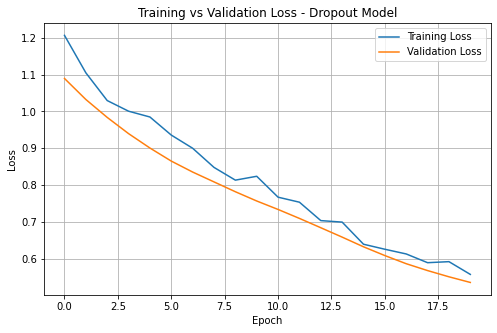

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(
    dropout_history.history["loss"],
    label="Training Loss"
)

plt.plot(
    dropout_history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss - Dropout Model")

plt.legend()
plt.grid(True)

plt.show()

![ChatGPT Image Sep 20, 2026, 09_07_44 PM.png](<attachment:ChatGPT Image Sep 20, 2026, 09_07_44 PM.png>)
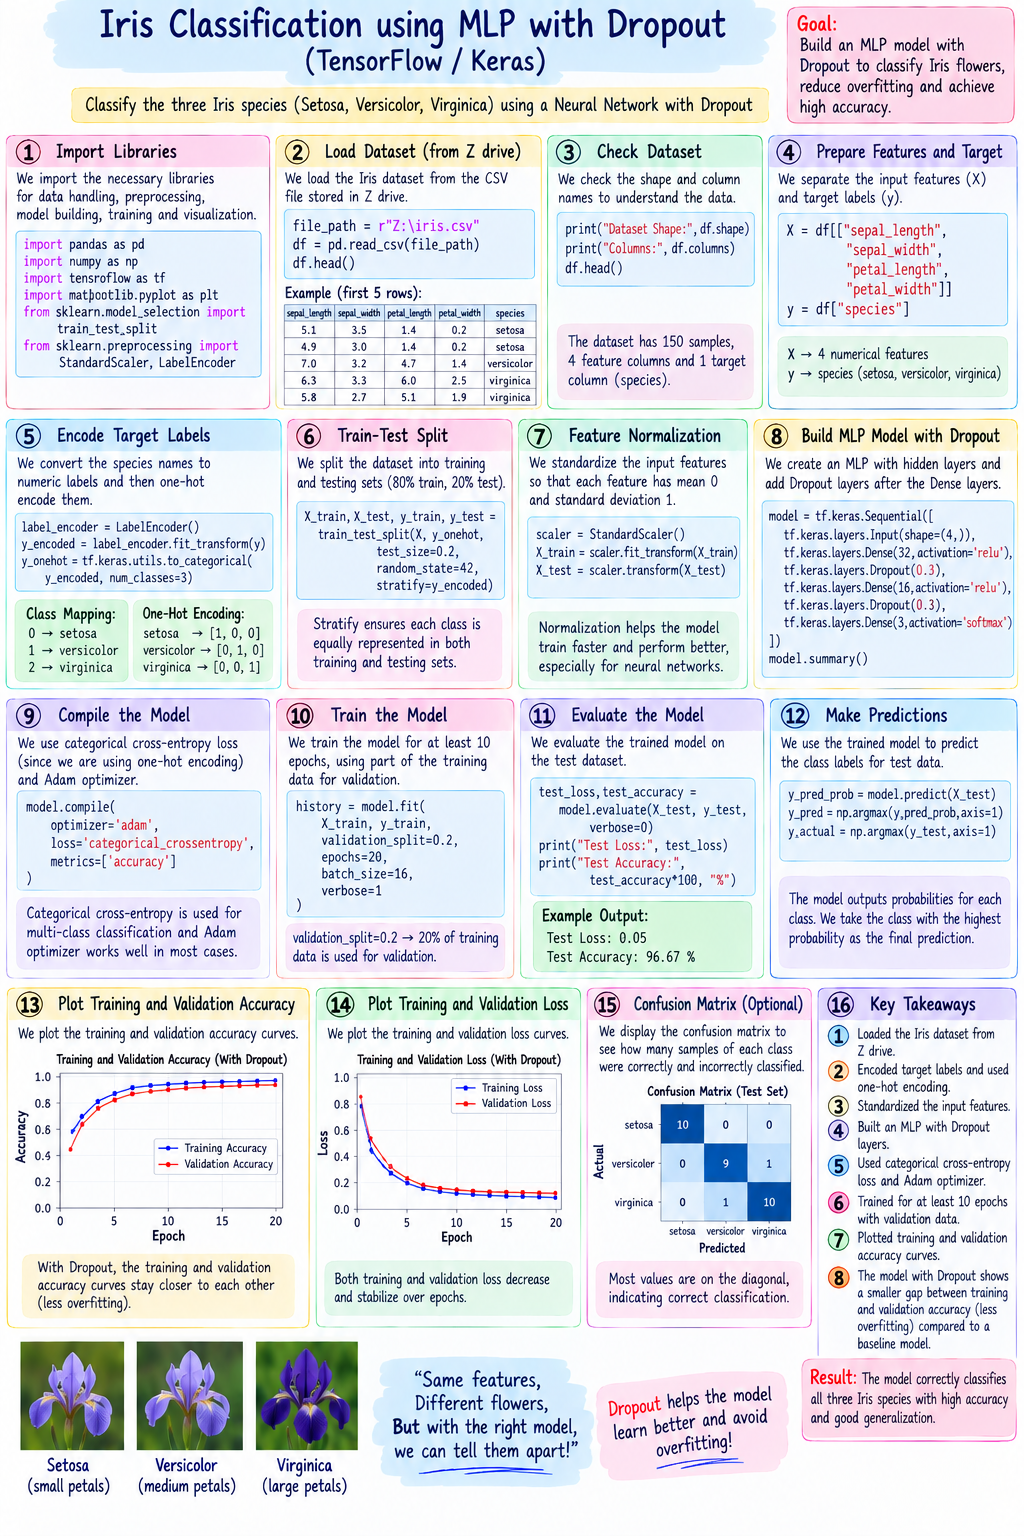